# Atoms, Ions, and Electrons

*Stellar Spectroscopy from Scratch — from physical principles to a working code*

Chapter 1 supplied a local `temperature` and material `gas_pressure` at each
depth. Chapter 2 supplied a declared linear elemental mixture and exact places to
store `electron_density`, `ion_stage_populations`, and
`partition_normalized_populations`. The field names are ready; their values are not.

At one depth the ideal-gas equation gives a particle budget,

$$
n_{\rm particle}=\frac{P_{\rm gas}}{k_{\rm B}T}.
$$

Take \(T=6000\) K and \(P_{\rm gas}=10^4\) dyn cm\(^{-2}\). With the rounded
constant used by the equation-of-state calculation, the budget is
\(1.21\times10^{16}\) particles cm\(^{-3}\). A pure-hydrogen gas could spend that
budget on \(1.21\times10^{16}\) neutral atoms and no electrons. It could also
contain \(8.05\times10^{15}\) hydrogen nuclei, half ionized, plus
\(4.02\times10^{15}\) free electrons. Both allocations satisfy the same particle
count. Neither has yet earned the title *equilibrium*.

The missing physical question is therefore:

> Given temperature, material gas pressure, and a linear elemental mixture, which
> atomic levels and ion stages are occupied, and which electron density makes those
> populations charge-consistent?

We will earn one answer:

> In an atom-only LTE gas, level weights and Boltzmann factors build each partition
> function, Saha ratios connect ion stages, and a damped charge-conservation fixed
> point closes the electron density.

**Assumptions.** The gas is ideal, in local thermodynamic equilibrium, and contains
atoms, ions, and free electrons. Each depth is a local thermodynamic problem. We
retain the one-dimensional, static, plane-parallel storage from Chapter 1, use CGS
units, and keep depth index 0 outermost. Molecules are disabled because they couple
elemental budgets and are the subject of Chapter 4—not because every atmosphere of
interest is warm.

`gas_pressure` is the material pressure after radiation pressure has been separated;
Chapter 1's `total_pressure` must not enter this calculation. We will first build
the physics with one transparent atom. Exact array shapes, table branches, and
CPU/device routes will appear only after the corresponding physical quantity has
earned a meaning.

> **Movement I — Count states at one depth.** We first stay inside one ion stage,
> then let an atom lose electrons, and finally see why a supplied electron density
> is not yet a closed material state.


In [1]:
from pathlib import Path
import sys

repository_root = Path.cwd()
if repository_root.name == "content":
    repository_root = repository_root.parent
if str(repository_root) not in sys.path:
    sys.path.insert(0, str(repository_root))
source_root = repository_root / "src"
if str(source_root) not in sys.path:
    sys.path.insert(0, str(source_root))

from book.plot_style import apply_book_plot_style

apply_book_plot_style()


In [2]:
import hashlib
import json
import os
from pathlib import Path
import time

import matplotlib.pyplot as plt
import numba
import numpy as np
import torch

from book.chapter03_runtime import (
    ATOM_ONLY_FIXTURE,
    available_backend_parity_profiles,
    compute_atmosphere_atomic_state,
    compute_atmosphere_atomic_state_by_depth,
    compute_atmosphere_atomic_energy_breakdown,
    compute_atmosphere_fixed_handoff_state,
    compute_atmosphere_saha_modes,
    compute_packed_bridge,
    compute_synthesis_atomic_states,
    configure_local_data_paths,
    load_atom_only_fixture,
    load_npz_arrays,
    load_synthesis_tables,
    probe_partition_branches,
    probe_pressure_lowering,
)
configure_local_data_paths()

from book.chapter03_support import (
    REFERENCE_HC_OVER_K_CM_K,
    damped_hydrogen_electron_fixed_point,
    fractional_doppler_width,
    neutral_collision_density_proxy,
    two_level_lte_populations,
    two_stage_saha_fractions,
)
from book.plot_style import (
    PAPER_COLORS,
    add_quiet_grid,
    single_panel,
)
from payne_zero_atmosphere.constants import (
    ATOMIC_MASS_GRAM_REFERENCE,
    BOLTZMANN_ERG_PER_K_REFERENCE,
    LIGHT_SPEED_CM_PER_S_EXACT,
    PLANCK_ERG_SECOND_REFERENCE,
    WAVENUMBER_PER_EV_REFERENCE,
)
from payne_zero_atmosphere.equation_of_state import (
    load_ionization_potential_table_cm,
    saha_partition_depth_batch,
)
from payne_zero_atmosphere.population_layout import (
    atomic_population_slot_start,
    decode_population_code,
    population_job_schedule,
)
from payne_zero_atmosphere.synthesis_bridge import (
    _packed_atomic_cube,
)
from payne_zero_synthesis.constants import (
    REFERENCE_ATOMIC_MASS_GRAM,
    REFERENCE_BOLTZMANN_ERG_PER_K,
    REFERENCE_BOLTZMANN_EV_PER_K,
    REFERENCE_PLANCK_ERG_SECOND,
    REFERENCE_SAHA_COEFFICIENT,
)
from payne_zero_synthesis.equation_of_state import (
    solve_population_state_at_electron_density,
)
from payne_zero_synthesis.pipeline import (
    compute_doppler_per_ion,
    load_atomic_masses,
)

repository_root = Path.cwd()
if repository_root.name == "content":
    repository_root = repository_root.parent
data_root = repository_root / "data"
golden_root = data_root / "golden" / "payne_zero"
manifest_path = data_root / "MANIFEST.json"
atom_only_inputs = load_atom_only_fixture()

def maximum_absolute_difference(left, right):
    left = np.asarray(left)
    right = np.asarray(right)
    finite = np.isfinite(left) & np.isfinite(right)
    if not np.array_equal(np.isfinite(left), np.isfinite(right)):
        return np.inf
    if not np.array_equal(
        left[~finite], right[~finite], equal_nan=True
    ):
        return np.inf
    if not np.any(finite):
        return 0.0
    return float(np.max(np.abs(left[finite] - right[finite])))

def sha256(path):
    return hashlib.sha256(Path(path).read_bytes()).hexdigest()

def timed_call(function, *args):
    start = time.perf_counter()
    result = function(*args)
    return result, time.perf_counter() - start


<figure>
  <img src="assets/schematics/textbook/ch03-levels-to-charge-v1.png"
       alt="Original textbook schematic moving from bound energy levels and statistical weights to a partition sum, a complete ion-stage ladder, a charge sum, and an explicit electron-density node that feeds every Saha ratio.">
<figcaption><strong>Conceptual schematic.</strong> Temperature distributes one ion
  stage over its levels; the partition sum normalizes that inventory; Saha ratios
  connect neighboring charge states. The charge sum updates the explicit \(n_e\)
  node, and that density enters every Saha ratio rather than one selected charge
  state. We will construct each arrow before trusting the complete loop.</figcaption>
</figure>

## 3.1 Excitation: one ion stage contains several levels

A **level** is one allowed energy of an atom or ion while its number of electrons
remains fixed. Set the ground level to energy \(E_0=0\). An upper level has an
excitation energy \(E_1-E_0\): energy stored inside the same ion stage rather than
spent removing an electron.

A tabulated level can stand for several quantum states with the same energy. Its
**statistical weight** \(g_i\) counts those states. For one angular-momentum value
\(J\), for example, \(g=2J+1\); we do not need angular-momentum coupling to use the
count.

LTE assigns the two levels the Boltzmann ratio

$$
\frac{n_1}{n_0}
=
\frac{g_1}{g_0}
\exp\!\left[-\frac{E_1-E_0}{k_{\rm B}T}\right].
$$

The source tables express excitation energies as wavenumbers
\(\tilde\nu\) in cm\(^{-1}\), so \(E=hc\tilde\nu\). Our transparent atom has
`energy_cm = [0, 10000]` and `statistical_weight = [2, 4]`.

This is also the first constant-tier boundary. Chapter 1 used exact constants for
Planck radiation. The production EOS retains rounded reference values—among them
\(h=6.6256\times10^{-27}\) erg s and
\(k_{\rm B}=1.38054\times10^{-16}\) erg K\(^{-1}\)—because changing those
literals changes parity-sensitive results. We keep the tiers separate.

Before calculating, the upper level should be rare when \(T\) is small, become more
populated as \(T\) rises, and approach \(g_1/g_0=2\) rather than infinity as
\(T\rightarrow\infty\).

**Cell contract.** Read temperature in K, two energies in cm\(^{-1}\), and two
dimensionless weights; write one dimensionless excited-to-ground ratio in NumPy
`float64` on CPU.


 3000 K: excited / ground = 0.016526
 6000 K: excited / ground = 0.181803
12000 K: excited / ground = 0.602997


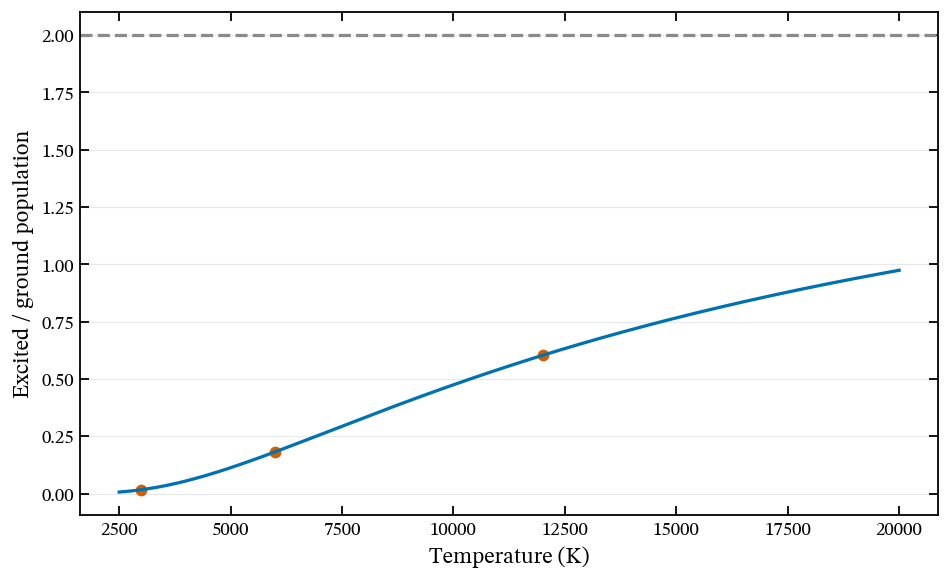

In [3]:
temperature_grid = np.linspace(2500.0, 20000.0, 500)
energy_cm = np.array([0.0, 10000.0])
statistical_weight = np.array([2.0, 4.0])
energy_gap_cm = energy_cm[1] - energy_cm[0]
excited_to_ground_ratio = (
    statistical_weight[1] / statistical_weight[0]
    * np.exp(
        -REFERENCE_HC_OVER_K_CM_K
        * energy_gap_cm
        / temperature_grid
    )
)
checkpoints = np.array([3000.0, 6000.0, 12000.0])
checkpoint_ratio = (
    statistical_weight[1] / statistical_weight[0]
    * np.exp(
        -REFERENCE_HC_OVER_K_CM_K * energy_gap_cm / checkpoints)
)
for temperature, ratio in zip(checkpoints, checkpoint_ratio):
    print(f"{temperature:5.0f} K: excited / ground = {ratio:.6f}")

figure, axes = single_panel()
axes.plot(
    temperature_grid,
    excited_to_ground_ratio,
    color=PAPER_COLORS["blue"],
)
axes.scatter(checkpoints, checkpoint_ratio, color=PAPER_COLORS["orange"])
axes.axhline(2.0, color=PAPER_COLORS["grey"], linestyle="--")
axes.set(xlabel="Temperature (K)", ylabel="Excited / ground population")
add_quiet_grid(axes, axis="y")
plt.show()
plt.close(figure)


The ratio rises from \(0.0165\) at 3000 K to \(0.1818\) at 6000 K and
\(0.6030\) at 12000 K. The upper level becomes easier to reach, but even the
hottest checkpoint remains well below the degeneracy limit of two. This is a ratio
*inside one ion stage*. It says nothing yet about whether the element is neutral or
ionized.

## 3.2 The partition function turns ratios into fractions

A population calculation needs fractions that sum to one. For element \(s\) and ion
stage \(r\), the **partition function**

$$
U_{s,r}(T)=\sum_i g_i e^{-E_i/(k_{\rm B}T)}
$$

is the weighted inventory of accessible levels. Each term is “number of states”
multiplied by “thermal accessibility.” It normalizes the level population:

$$
\frac{n_i}{n_{s,r}}
=
\frac{g_i e^{-E_i/(k_{\rm B}T)}}{U_{s,r}},
\qquad
\sum_i\frac{n_i}{n_{s,r}}=1.
$$

Chapter 2 named two same-shaped population arrays and used a placeholder \(U=4\).
We can now compute \(U\) from actual levels. If
\(n_{s,r}=10^{12}\) cm\(^{-3}\), then the reusable quantity
\(n_{s,r}/U_{s,r}\) must reconstruct every bound level through

$$
n_i=
\left(\frac{n_{s,r}}{U_{s,r}}\right)
g_i e^{-E_i/(k_{\rm B}T)}.
$$

**Cell contract.** Read the two-level model and an actual ion-stage population in
cm\(^{-3}\); write \(U\), two level fractions, and the reconstructed level
populations in CPU `float64`.


In [4]:
partition_function, level_fraction = two_level_lte_populations(
    checkpoints,
    energy_cm,
    statistical_weight,
)
ion_stage_population = np.full(checkpoints.size, 1.0e12)
partition_normalized_population = (
    ion_stage_population / partition_function
)
level_weight = statistical_weight[None, :] * np.exp(
    -REFERENCE_HC_OVER_K_CM_K
    * energy_cm[None, :]
    / checkpoints[:, None]
)
reconstructed_levels = (
    partition_normalized_population[:, None] * level_weight
)
expected_levels = ion_stage_population[:, None] * level_fraction
for index, temperature in enumerate(checkpoints):
    print(
        f"{temperature:5.0f} K  U={partition_function[index]:.6f}  "
        f"fractions={level_fraction[index]}  "
        f"sum={level_fraction[index].sum():.16f}"
    )
print(
    "maximum reconstruction difference:",
    maximum_absolute_difference(reconstructed_levels, expected_levels),
)
print(
    "maximum relative reconstruction difference:",
    np.max(
        np.abs(reconstructed_levels - expected_levels)
        / ion_stage_population[:, None]
    ),
)


 3000 K  U=2.033052  fractions=[0.98374257 0.01625743]  sum=1.0000000000000000
 6000 K  U=2.363605  fractions=[0.84616496 0.15383504]  sum=1.0000000000000000
12000 K  U=3.205994  fractions=[0.6238315 0.3761685]  sum=1.0000000000000000
maximum reconstruction difference: 6.103515625e-05
maximum relative reconstruction difference: 6.103515625e-17


The level fractions sum to one to floating-point precision at all three
temperatures. Reconstructing values of order \(10^{12}\) cm\(^{-3}\) differs by at
most \(6.10\times10^{-5}\) cm\(^{-3}\), or \(6.10\times10^{-17}\) relative to
the declared ion-stage population. Temperature redistributes a fixed population; it
creates no particles.

We can now attach the exact public meanings:

- `ion_stage_populations` stores actual \(n_{s,r}\) in cm\(^{-3}\);
- `partition_normalized_populations` stores \(n_{s,r}/U_{s,r}\) in
  cm\(^{-3}\) per dimensionless partition function.

The second quantity is not a fraction and not a bound-level population. It is useful
because many later line calculations can multiply the same \(n/U\) by their own
\(g_i e^{-E_i/(kT)}\).

A normalized level inventory is now available. The next missing rule is physical,
not computational: how much of an element occupies each ion stage?


In [5]:
manifest = json.loads(manifest_path.read_text(encoding="utf-8"))
chapter03_paths = {
    "data/static/atmosphere_tables/isotope_tables.npz",
    "data/static/atmosphere_tables/packed_level_metadata.npz",
    "data/static/atmosphere_tables/special_partition_tables.npz",
    "data/static/atmosphere_tables/iron_group_partition_tables.npz",
    "data/static/atmosphere_tables/ionization_potential_tables.npz",
    "data/static/synthesis_tables/atomic_masses.npz",
    "data/static/synthesis_tables/partition_saha_tables.npz",
    "data/fixtures/chapter03_synthesis_eos_state.npz",
    "data/fixtures/chapter03_atom_only_inputs.npz",
}
entries = {
    entry["path"]: entry
    for entry in manifest["entries"]
    if entry["path"] in chapter03_paths
}
assert set(entries) == chapter03_paths
assert all(
    sha256(repository_root / path) == entries[path]["sha256"]
    for path in chapter03_paths
)
fixture_sha256 = sha256(ATOM_ONLY_FIXTURE)
def verify_golden_identity(arrays):
    assert str(arrays["fixture_sha256"]) == fixture_sha256
    assert str(arrays["payne_zero_commit"]) == manifest[
        "payne_zero_commit"
    ]


## 3.3 Removing an electron: the Saha ladder

An **ion stage** records how many electrons a nucleus has lost. Because three common
conventions coexist, we fix them before writing the equation:

| physical species | charge \(q\) | spectroscopic label | public axis index |
| --- | ---: | --- | ---: |
| neutral hydrogen | 0 | H I | 0 |
| singly ionized hydrogen | 1 | H II | 1 |

In mathematics we use \(r=q=0,1,\ldots\), with the neutral stage first. An exact
helper that accepts one-based `ion_stage` will be labeled at its call site. The
public six-stage axis is storage capacity, not a claim that every element has six
physically meaningful stages.

The local reaction is “stage \(r\) becomes stage \(r+1\) plus one free electron.”
LTE gives the adjacent-stage Saha relation

$$
\frac{n_{s,r+1}n_e}{n_{s,r}}
=
\frac{2U_{s,r+1}}{U_{s,r}}
\left(\frac{2\pi m_e k_{\rm B}T}{h^2}\right)^{3/2}
\exp\!\left[
  -\frac{\mathcal I_{s,r}-\Delta\mathcal I_{s,r}}
  {k_{\rm B}T}
\right].
$$

Here \(s\) identifies the element, \(m_e\) is the electron mass, and the leading
factor two counts the free electron's two spin states under this partition
convention. The partition ratio counts internal states on the two ionic sides. The
\(T^{3/2}\) term counts translational states available to the released electron.

That last term is worth a moment, because it reappears throughout the book. A
free electron at temperature \(T\) cannot be localized more finely than its
thermal de Broglie wavelength
\(\Lambda=h/\sqrt{2\pi m_e k_{\rm B}T}\), so the number of distinct places it
can be put per unit volume is \(1/\Lambda^3\):

$$
\frac{1}{\Lambda^3}
=\left(\frac{2\pi m_e k_{\rm B}T}{h^2}\right)^{3/2}
=2.4148\times10^{15}\,T^{3/2}\ {\rm cm^{-3}} .
$$

Ionization is favoured at high temperature partly because the freed electron has
so many more states to occupy. We will meet the constant
\(2.4148\times10^{15}\) again in §5.3, where the same factor runs in reverse as
an electron is captured rather than released.

The exponential pays the **ionization energy** \(\mathcal I\). Electron density appears
on the left, so crowding free electrons favors recombination. The right side has
units of number density, matching \(n_{r+1}n_e/n_r\).

We first set the dense-plasma lowering
\(\Delta\mathcal I=0\) and declare the ground-only values
\(U_{\rm H\,I}=2\), \(U_{\rm H\,II}=1\). This isolates the Saha balance from the
production occupation corrections that we will add only after this transparent
calculation is understood. In the code, the explicit
electron-spin factor `2.0` and the explicit partition ratio `1.0 / 2.0` cancel; both
remain written so the numerical line can be read directly against the equation.
At fixed \(n_e\), higher
temperature should favor H II; larger \(n_e\) would favor H I. The complete
two-stage ladder must normalize to one, but its result is conditional on the supplied
electron density.

**Cell contract.** Read an exact H partition over temperature, one declared fixed
`electron_density`, and the exact tabulated H I ionization energy; write stable H I
and H II fractions in CPU `float64`.


H I ionization energy (eV): 13.598543124345124
cool fractions: 0.9999999999986896 1.3104271977063228e-12
hot fractions: 1.5344524086232118e-07 0.9999998465547588


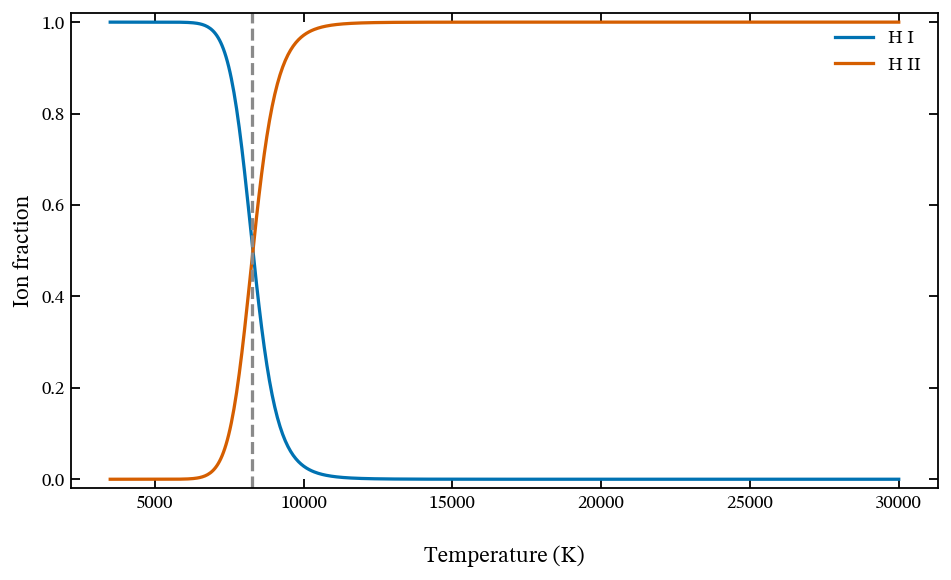

In [6]:
saha_temperature_grid = np.linspace(3500.0, 30000.0, 600)
fixed_electron_density = np.full_like(saha_temperature_grid, 1.0e13)
hydrogen_ionization_energy_ev = (
    load_ionization_potential_table_cm()[0]
    / WAVENUMBER_PER_EV_REFERENCE)
log_saha_ratio = (
    np.log(2.0 * REFERENCE_SAHA_COEFFICIENT)
    + np.log(1.0 / 2.0)
    + 1.5 * np.log(saha_temperature_grid)
    - np.log(fixed_electron_density)
    - hydrogen_ionization_energy_ev
    / (REFERENCE_BOLTZMANN_EV_PER_K * saha_temperature_grid)
)
log_normalizer = np.logaddexp(0.0, log_saha_ratio)
hydrogen_neutral_fraction = np.exp(-log_normalizer)
hydrogen_ionized_fraction = np.exp(log_saha_ratio - log_normalizer)
crossing_index = int(np.argmin(abs(hydrogen_neutral_fraction - 0.5)))
print("H I ionization energy (eV):", hydrogen_ionization_energy_ev)
for label, index in (("cool", 0), ("hot", -1)):
    print(label, "fractions:", hydrogen_neutral_fraction[index],
          hydrogen_ionized_fraction[index])
crossing_temperature = saha_temperature_grid[crossing_index]

figure, axes = single_panel()
axes.plot(saha_temperature_grid, hydrogen_neutral_fraction,
          color=PAPER_COLORS["blue"], label="H I")
axes.plot(saha_temperature_grid, hydrogen_ionized_fraction,
          color=PAPER_COLORS["orange"], label="H II")
axes.axvline(crossing_temperature, color=PAPER_COLORS["grey"],
             linestyle="--")
axes.set(xlabel="Temperature (K)", ylabel="Ion fraction", ylim=(-0.02, 1.02))
axes.xaxis.set_label_coords(0.5, -0.12)
axes.legend()
plt.show()
plt.close(figure)


At 3500 K the H II fraction is only \(1.31\times10^{-12}\). At 30000 K the H I
minority is \(1.53\times10^{-7}\), and the nearest 50/50 sample lies at 8278 K for the declared
\(n_e=10^{13}\) cm\(^{-3}\). This is the first ion-fraction curve in the chapter
because every value is traceable to a derived equation, declared ground-only
partitions, an exact ionization energy, and a stated density. It is not yet a
charge-closed gas.

The readable calculation used log space to retain a tiny minority stage. That is also
the production synthesis strategy. The atmosphere scalar kernel instead forms direct
`float64` ratios and normalizes them in reverse stage order. It clamps temperature to
at least 1 K and electron density to at least \(10^{-40}\) cm\(^{-3}\); exact
parity claims therefore use the declared physical fixture rather than artificial
extremes.

## 3.4 Real atoms need several partition recipes

The transparent Saha curve used two declared ground-state partitions. A real
calculation must now answer where \(U_{s,r}(T)\) comes from for every ion. No single
table represents all atoms equally well:

| branch | physical reason |
| --- | --- |
| special ordered levels | selected H, He, and metal stages have explicit level lists |
| packed ordinary interpolation | most ions use compact tabulated partitions |
| PFIRON interpolation | \(Z=20\ldots28\) use a lowering/temperature/stage grid |

The atmosphere and synthesis stacks are separately exact. Their helper stages,
low-temperature floors, and high-lowering edge policies are not interchangeable.
The synthesis low-temperature correction is itself an ordered level sum:
`ground_partition_value` adds one base weight and then `(weight, energy_cm)` pairs.
Below \(2T_{\rm ref}\), the runtime uses
\(\max(U_{\rm current},U_{\rm ground})\). This selects a floor; it does not add two
physical inventories.

The hidden setup has already applied Chapter 2's manifest rule: nine static/fixture
assets have distinct identities and exact hashes. We print that compact preflight
here, at the point where those tables first affect a physical result. The loaded
`(605,80)` `ground_partition_table` is required depth-specific fixture state but is
not the active ordered-level lookup.

**Cell contract.** Read the manifest plus H, Ne, and Fe cases at four temperatures;
write asset identity, exact partition arrays, branch labels, and one synthesis
ground-floor on/off diagnostic in native CPU `float64`.


In [7]:
for path in sorted(chapter03_paths):
    entry = entries[path]
    print(
        f"{entry['role']:7s} arrays={len(entry['arrays']):2d} "
        f"sha=exact {Path(path).name}"
    )
partition_probe = probe_partition_branches(atom_only_inputs)
print("EOS reference k_B, h, Saha coefficient, m_u:")
print(
    REFERENCE_BOLTZMANN_ERG_PER_K,
    REFERENCE_PLANCK_ERG_SECOND,
    REFERENCE_SAHA_COEFFICIENT,
    REFERENCE_ATOMIC_MASS_GRAM,
)
for atomic_number, branch in zip(
    partition_probe["atomic_number"],
    partition_probe["branch_label"],
):
    atmosphere_values = partition_probe[
        f"atmosphere_z{int(atomic_number):02d}_partition"
    ]
    synthesis_values = partition_probe[
        f"synthesis_z{int(atomic_number):02d}_partition"
    ]
    print(f"Z={atomic_number:2d}: {branch}")
    print("  atmosphere/synthesis first-stage U:",
          atmosphere_values[:, 0], synthesis_values[:, 0])
    print("  minimum U:",
          min(atmosphere_values.min(), synthesis_values.min()))
print("O II ordered / floor on / floor off:",
      partition_probe["ground_floor_ordered_value"][0],
      partition_probe["ground_floor_enabled_partition"][0],
      partition_probe["ground_floor_disabled_partition"][0])


fixture arrays=15 sha=exact chapter03_atom_only_inputs.npz
fixture arrays=11 sha=exact chapter03_synthesis_eos_state.npz
static  arrays= 1 sha=exact ionization_potential_tables.npz
static  arrays= 1 sha=exact iron_group_partition_tables.npz
static  arrays= 2 sha=exact isotope_tables.npz
static  arrays= 1 sha=exact packed_level_metadata.npz
static  arrays=29 sha=exact special_partition_tables.npz
static  arrays= 1 sha=exact atomic_masses.npz
static  arrays=39 sha=exact partition_saha_tables.npz


EOS reference k_B, h, Saha coefficient, m_u:
1.38054e-16 6.6256e-27 2414800000000000.0 1.66e-24
Z= 1: special ordered levels
  atmosphere/synthesis first-stage U: [2.         2.         2.00108202 2.35790764] [2.00000000e+00 2.00000001e+00 2.16493781e+00 8.08364169e+03]
  minimum U: 1.0
Z=10: packed ordinary
  atmosphere/synthesis first-stage U: [1.         1.         1.         1.32041466] [1.         1.         1.         2.38115982]
  minimum U: 1.0
Z=26: PFIRON
  atmosphere/synthesis first-stage U: [ 23.23668337  27.79393317  60.584      505.37640186] [ 23.23668337  27.79393317  60.584      935.683026  ]
  minimum U: 6.0
O II ordered / floor on / floor off: 4.000025946329889 4.000025946329889 3.34678558700523


Every partition is at least one, as a level inventory containing a ground state must
be. At 30000 K, the first H partition is 2.36 in the atmosphere stack and
\(8.08\times10^3\) in the synthesis stack; Fe I is 505.38 versus 935.68. Those
differences occur at policy edges and are exactly why the stacks remain distinct.

For O II at 3000 K, the ordered ground sum is 4.000026. Enabling the correction
floors the active synthesis partition at that value; disabling it leaves 3.346786.
The `(605,80)` fixture field did not enter that evaluation. Hashes establish which
physical tables were used; the numerical checks establish what they did.

The exact atmosphere interface then restores its density-dependent partitions and
exposes three useful modes:

- mode 11 returns stage fraction divided by \(U\);
- mode 12 returns actual stage fraction;
- mode 13 returns \(U\).

The scalar kernel accepts nuclei density and elemental abundance to preserve its exact
call contract, but it does not apply either scale. The caller later multiplies by
\(n_{\rm nuclei}A_s\) to obtain cm\(^{-3}\).

**Cell contract.** Read the exact H, Ne, and Fe scalar/batch fixture; write modes 11,
12, and 13, representation identities, stored-stage deficits, and comparisons loaded
only after the local calculation.


In [8]:
atmosphere_saha_modes = compute_atmosphere_saha_modes(atom_only_inputs)
saha_golden_path = (
    golden_root / "chapter03_atmosphere_saha_outputs.npz"
)
saha_golden = load_npz_arrays(saha_golden_path)
verify_golden_identity(saha_golden)
stage_counts = {1: 2, 10: 6, 26: 5}
for atomic_number, stage_count in stage_counts.items():
    prefix = f"z{atomic_number:02d}"
    divided = atmosphere_saha_modes[f"{prefix}_mode11_batch"]
    fraction = atmosphere_saha_modes[f"{prefix}_mode12_batch"]
    partition = atmosphere_saha_modes[f"{prefix}_mode13_batch"]
    scalar_difference = maximum_absolute_difference(
        fraction,
        atmosphere_saha_modes[f"{prefix}_mode12_scalar"],
    )
    reconstruction = maximum_absolute_difference(
        fraction,
        divided * partition,
    )
    golden_difference = max(
        maximum_absolute_difference(
            atmosphere_saha_modes[name], saha_golden[name]
        )
        for name in atmosphere_saha_modes
        if name.startswith(prefix)
    )
    deficit = 1.0 - fraction.sum(axis=1)
    print(
        f"Z={atomic_number:2d} stages={stage_count}: "
        f"scalar/batch={scalar_difference:.3e}, "
        f"f-U(f/U)={reconstruction:.3e}, "
        f"deficit=[{deficit.min():.3e}, {deficit.max():.3e}], "
        f"golden={golden_difference:.3e}"
    )


Z= 1 stages=2: scalar/batch=0.000e+00, f-U(f/U)=0.000e+00, deficit=[0.000e+00, 1.110e-16], golden=0.000e+00
Z=10 stages=6: scalar/batch=0.000e+00, f-U(f/U)=1.323e-23, deficit=[0.000e+00, 1.110e-16], golden=0.000e+00
Z=26 stages=5: scalar/batch=0.000e+00, f-U(f/U)=1.110e-16, deficit=[-2.220e-16, 3.434e-03], golden=0.000e+00


Scalar and batch rows are bit-identical on the pinned CPU path. Reconstruction is
exact for H, within \(1.32\times10^{-23}\) for Ne, and within
\(1.11\times10^{-16}\) for Fe. The five stored Fe stages leave a maximum deficit
of 0.00343 because helper stages participate in normalization. The tiny negative end
of the printed Fe deficit interval is roundoff at a sum that is physically one, not a
negative missing population. Only after these local identities were established did
the cell load the goldens; every difference is zero.

## 3.5 Dense plasma changes the last bound levels

The isolated-atom ladder assumes every bound level remains distinct. In a plasma,
surrounding charges screen the nucleus. The characteristic **Debye radius**

$$
r_D=\sqrt{\frac{k_{\rm B}T}{4\pi e^2 n_{q^2}}}
$$

Here \(e\) is the elementary charge in electrostatic CGS units and
\(n_{q^2}=n_e+\sum_{s,r}q_r^2n_{s,r}\) is the
**charge-square number density** in cm\(^{-3}\). It weights a doubly ionized ion
four times, not twice. The radius shortens as \(n_{q^2}\) increases. Stronger screening lowers the
energy needed to ionize and dissolves the highest bound levels. The reference
lowering per unit charge is

$$
\Delta\mathcal I_1
=
\min\!\left(1,\frac{1.44\times10^{-7}}{r_D}\right)
\ {\rm eV},
$$

with the one-eV cap applied before the stage-charge multiplier.

The two exact stacks estimate the screening environment differently. Atmosphere
closure eventually accumulates the explicit \(n_e+\sum q_r^2n_{s,r}\); before the
first population update it seeds a proxy with \(2n_e\) and adds twice any positive
excess of \(2n_e-P_{\rm gas}/(kT)\). Synthesis rebuilds that pressure/electron proxy
on each evaluation. The remaining policy is branch-specific:

| branch | atmosphere policy | synthesis policy |
| --- | --- | --- |
| special levels | always evaluates its ordered level sum; selected species carry their own occupation cutoff | H I, He I, and He II expose their excited-level sums only at \(T\ge9000,\ 15000,\ 30000\) K; their occupation cutoff can bypass the ordinary high-\(T\) gate |
| ordinary packed | below \(2T_{\rm ref}\), use the packed interpolation; above \(4T_{\rm ref}\), add occupation states only when stage lowering is at least 0.1 eV | below \(2T_{\rm ref}\), optionally floor with the ordered ground sum; the same \(4T_{\rm ref}\) and 0.1-eV gates control the ordinary occupation addition |
| PFIRON | interpolate \(Z=20\ldots28\), then clamp lowering beyond the final grid node | interpolate the same element range but extrapolate beyond the final lowering node |

These are production definitions, not knobs to blend into a “cleaner” universal
correction. A branch name alone is therefore insufficient: temperature, charge
environment, and edge policy are part of the calculation.

We compare a dilute and a dense case at the same 30000 K. The Debye radius should
shrink, the per-charge lowering should rise but not exceed one eV, and every
partition should remain at least one.

**Cell contract.** Read two controlled positive plasma states; write each stack's
Debye radius, lowering, H/Fe partitions, and exact policy label in CPU `float64`.


In [9]:
lowering_probe = probe_pressure_lowering()
print("controlled T (K):", lowering_probe["temperature"])
print("controlled ne (cm^-3):", lowering_probe["electron_density"])
print("controlled Pgas (dyn cm^-2):", lowering_probe["gas_pressure"])
for stack in ("atmosphere", "synthesis"):
    radius = lowering_probe[f"{stack}_debye_radius_cm"]
    lowering = lowering_probe[f"{stack}_lowering_per_charge_ev"]
    hydrogen = lowering_probe[f"{stack}_h_partition"]
    iron = lowering_probe[f"{stack}_fe_partition"]
    print(f"\n{stack}: {lowering_probe[f'{stack}_policy_label']}")
    for index, label in enumerate(("dilute", "dense")):
        print(
            f"  {label:6s}: r_D={radius[index]:.6e} cm, "
            f"lowering={lowering[index]:.6e} eV, "
            f"U(H I)={hydrogen[index, 0]:.6f}, "
            f"U(Fe I)={iron[index, 0]:.6f}"
        )
    print("  radius shrank:", radius[1] < radius[0])
    print("  one-eV cap respected:", np.max(lowering) <= 1.0)
    print(
        "  all displayed partitions >= 1:",
        min(float(hydrogen.min()), float(iron.min())) >= 1.0,
    )
print("\nPFIRON edge: Mn IV at",
      lowering_probe["pfiron_edge_temperature"][0], "K")
print("lowering coordinate (cm^-1):",
      lowering_probe["pfiron_edge_lowering_coordinate_cm"][0])
print("atmosphere clamp / synthesis extrapolation:",
      lowering_probe["pfiron_edge_atmosphere_partition"][0],
      lowering_probe["pfiron_edge_synthesis_partition"][0])


controlled T (K): [30000. 30000.]
controlled ne (cm^-3): [1.e+13 1.e+20]
controlled Pgas (dyn cm^-2): [6.21243e+01 6.21243e+08]

atmosphere: explicit charge-square density; PFIRON clamps above final node
  dilute: r_D=2.183169e-04 cm, lowering=6.595916e-04 eV, U(H I)=10255.722731, U(Fe I)=935.683026
  dense : r_D=6.903786e-08 cm, lowering=1.000000e+00 eV, U(H I)=2.357908, U(Fe I)=505.376402
  radius shrank: True
  one-eV cap respected: True
  all displayed partitions >= 1: True

synthesis: pressure/electron proxy; PFIRON extrapolates above final node
  dilute: r_D=2.183171e-04 cm, lowering=6.595911e-04 eV, U(H I)=5965.576721, U(Fe I)=935.683026
  dense : r_D=6.903793e-08 cm, lowering=1.000000e+00 eV, U(H I)=2.643554, U(Fe I)=505.376402
  radius shrank: True
  one-eV cap respected: True
  all displayed partitions >= 1: True

PFIRON edge: Mn IV at 50000.0 K
lowering coordinate (cm^-1): 32261.916
atmosphere clamp / synthesis extrapolation: 107.83128639650374 107.8287736910793


Raising the density shortens \(r_D\) by several orders of magnitude and drives the
per-charge lowering from about \(6.6\times10^{-4}\) eV to its one-eV cap. The
resulting H and Fe partitions expose the separate occupation policies without
requiring them to agree. This pair of states crosses one controlled policy boundary;
it does not certify every special species. The separate 50000 K Mn IV probe reaches
a lowering coordinate of \(3.2262\times10^4\) cm\(^{-1}\), beyond the final
PFIRON node. The atmosphere clamp gives \(U=107.8313\), while synthesis
extrapolation gives \(U=107.8288\). The small numerical separation is valuable
precisely because it proves that two distinct edge policies were executed.

We can now evaluate ion stages for a supplied \(n_e\). We still cannot call the gas
neutral, because the stage populations themselves determine how many free electrons
should exist.

> **Movement II — Close the atomic gas.** A trial electron density selects a charge
> distribution, and that distribution predicts another electron density. We now
> iterate until those two statements agree.

## 3.6 One element exposes the electron feedback

In an atom-only ideal gas,

$$
\frac{P_{\rm gas}}{k_{\rm B}T}
=
n_{\rm nuclei}+n_e,
\qquad
n_e=\sum_s\sum_r q_r n_{s,r}.
$$

The first equation turns a trial \(n_e\) into a nuclei density. Saha uses that trial
to divide each element among ion stages. The second equation turns those populations
into a new \(n_e\). A **fixed point** is a value left unchanged by this complete
update.

Neither production stack uses Newton's method for atom-only charge closure. No
derivative or Jacobian is formed. Both retain the damped rule

$$
n_e^{\rm raw}=\hbox{charge from current populations},\quad
n_e^{\rm bounded}=\max(n_e^{\rm raw},0.5n_e^{\rm old}),\quad
n_e^{\rm new}=\tfrac12(n_e^{\rm bounded}+n_e^{\rm old}).
$$

The bound and half-step imply that one update cannot reduce \(n_e\) below 75 percent
of its previous value. We trace the same arithmetic for hydrogen alone before summing
99 elements.

**Cell contract.** Read one positive \(T\), \(P_{\rm gas}\), and electron seed;
write the old, raw, and damped densities plus the relative fixed-point residual in
CPU `float64`.


old ne          raw charge      updated ne      residual
 1.000000e+12  1.578031e+16  7.890657e+15  9.998733e-01
 7.890657e+15  5.169743e+13  5.917993e+15  3.333333e-01
 5.917993e+15  8.532079e+13  4.438495e+15  3.333333e-01
iterations: 12
final electron density: 848722710020100.9
final residual: 2.5150655064354824e-08
smallest new/old ratio: 0.7499999999999999
damping arithmetic difference: 0.0
invalid seed rejected: electron-density seed must leave a positive nuclei density


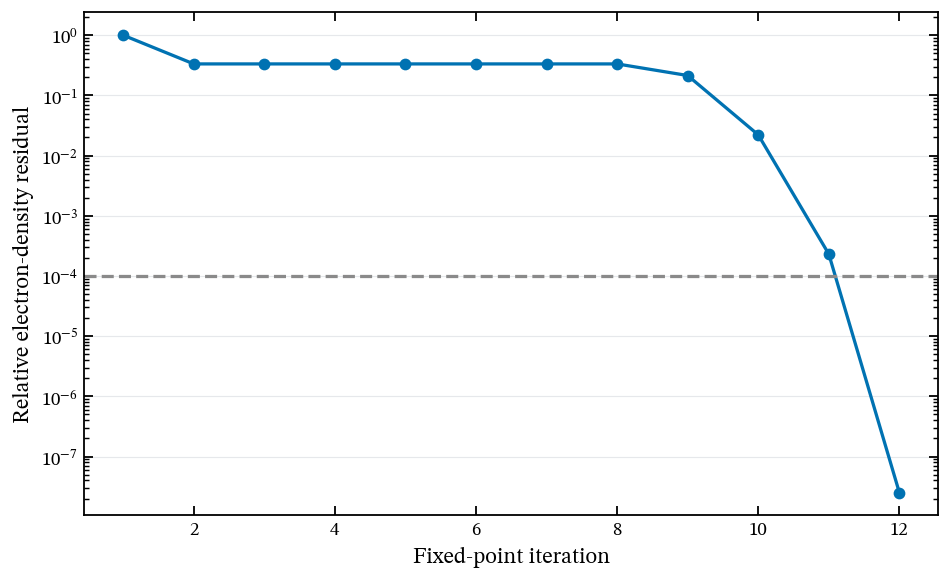

In [10]:
hydrogen_closure = damped_hydrogen_electron_fixed_point(
    temperature_k=9000.0, gas_pressure_dyn_cm2=2.0e4,
    electron_density_seed_cm3=1.0e12,
    ionization_energy_ev=hydrogen_ionization_energy_ev)
closure_history = np.asarray(hydrogen_closure["history"])
print("old ne          raw charge      updated ne      residual")
for row in closure_history[:3]:
    print(" ".join(f"{value:13.6e}" for value in row))
reconstructed_update = 0.5 * (
    np.maximum(closure_history[:, 1], 0.5 * closure_history[:, 0])
    + closure_history[:, 0])
print("iterations:", len(closure_history))
print("final electron density:", hydrogen_closure["electron_density_cm3"])
print("final residual:", closure_history[-1, 3])
print("smallest new/old ratio:",
      np.min(closure_history[:, 2] / closure_history[:, 0]))
print("damping arithmetic difference:", maximum_absolute_difference(
    reconstructed_update, closure_history[:, 2]))
try:
    damped_hydrogen_electron_fixed_point(
        temperature_k=9000.0, gas_pressure_dyn_cm2=2.0e4,
        electron_density_seed_cm3=1.0e30,
        ionization_energy_ev=hydrogen_ionization_energy_ev)
except ValueError as error:
    print("invalid seed rejected:", error)

figure, axes = single_panel()
axes.semilogy(np.arange(1, len(closure_history) + 1),
              closure_history[:, 3], marker="o", color=PAPER_COLORS["blue"])
axes.axhline(1.0e-4, color=PAPER_COLORS["grey"], linestyle="--")
axes.set(xlabel="Fixed-point iteration",
         ylabel="Relative electron-density residual")
add_quiet_grid(axes, axis="y")
plt.show()
plt.close(figure)


The first step moves sharply because the seed is far from the charge implied by hot
hydrogen. Subsequent reductions follow the damping floor: the smallest printed
`new / old` ratio is 0.75, exactly the predicted 25-percent maximum drop. After 12
updates the residual is \(2.5\times10^{-8}\), below the declared \(10^{-4}\)
tolerance.

This readable trace has a strict domain. A seed at or above
\(P_{\rm gas}/(kT)\) leaves no positive nuclei density and is rejected rather than
“repaired” into a result; the cell deliberately supplies \(10^{30}\) cm\(^{-3}\)
and prints the rejection. The atmosphere scalar kernel likewise does not make an
invalid upstream state physical. Both synthesis routes floor their
\(P_{\rm gas}/(kT)-n_e\) nuclei difference at \(10^{-300}\) for numerical safety;
in the fixed-density route this is a boundary policy, not charge closure.

## 3.7 Ninety-nine elements close one depth

For a stellar mixture, the caller walks elements in ascending atomic number. At a
trial electron density it obtains

$$
n_{s,r}=n_{\rm nuclei}A_s f_{s,r},
$$

where \(A_s\) is the linear abundance from Chapter 2 and \(f_{s,r}\) is the
mode-12 stage fraction. The deck intends \(A_s\) as a number fraction per nucleus,
so \(\sum_s A_s\) should be near one. The exact stored mixture is not silently
renormalized: its sum is \(0.9999996127701212\), short of literal unity by
\(3.8723\times10^{-7}\). Each abundance is applied once. The retained positive
charge is summed, damped, and returned to the next orbit.

Two exact details matter when we assess the result. First, helper stages can
normalize a ladder without appearing in the stored subset. Second, the population
evaluation immediately before the final density update can be one orbit behind that
final \(n_e\). The atmosphere schedule refreshes its packed arrays afterward. The
synthesis atom-only full solver does not add that refresh.

Our six-depth fixture samples cool, solar-like, and hot states from a source-derived
column but is an integration fixture, not a newly converged atmosphere. We close its
atom-only mixture and then measure the particle and charge identities from the
refreshed packed arrays.

**Cell contract.** Read six depth rows, a 99-element linear mixture, and positive
seeds; write the exact refreshed atmosphere density and `(D,1006)` population state
in NumPy/Numba `float64` on CPU.


In [11]:
atmosphere_atomic_state = compute_atmosphere_atomic_state(atom_only_inputs)
atmosphere_public_state = compute_packed_bridge(atmosphere_atomic_state)
public_charge = np.sum(
    atmosphere_public_state["ion_stage_populations"][:, :, :99]
    * np.arange(6, dtype=np.float64)[None, :, None],
    axis=(1, 2),
)
electron_density = atmosphere_atomic_state["electron_density"]
charge_residual = np.abs((electron_density - public_charge)
                         / np.maximum(electron_density, 1.0e-300))
particle_budget = atom_only_inputs["gas_pressure"] / (
    BOLTZMANN_ERG_PER_K_REFERENCE * atom_only_inputs["temperature"])
particle_difference = maximum_absolute_difference(
    particle_budget, electron_density + atmosphere_atomic_state[
        "total_nuclei_number_density"])
abundance_sum = atom_only_inputs["elemental_abundances"].sum()
packed_population_scale = atmosphere_atomic_state[
    "ion_stage_populations_by_packed_slot"
].sum(axis=1) / atmosphere_atomic_state[
    "total_nuclei_number_density"]
print("maximum particle-identity difference:", particle_difference)
print("maximum refreshed charge residual:", charge_residual.max())
print("abundance sum / shortfall from one:",
      abundance_sum, 1.0 - abundance_sum)
print("maximum population-scale difference:",
      np.max(np.abs(packed_population_scale - abundance_sum)))
print("electron density (cm^-3):", electron_density)
print("mass density (g cm^-3):", atmosphere_atomic_state["mass_density"])
print("packed actual shape:", atmosphere_atomic_state[
    "ion_stage_populations_by_packed_slot"
].shape)


maximum particle-identity difference: 0.0
maximum refreshed charge residual: 4.20399114926539e-05
abundance sum / shortfall from one: 0.9999996127701212 3.8722987882877646e-07
maximum population-scale difference: 3.3306690738754696e-16
electron density (cm^-3): [9.49903825e+07 1.01921129e+09 1.36697695e+10 6.72743879e+11
 1.20203323e+16 3.13950938e+18]
mass density (g cm^-3): [1.16781345e-14 1.18552775e-12 1.18638237e-10 1.10868516e-08
 5.09557993e-07 7.24013913e-06]
packed actual shape: (6, 1006)


The particle identity is exact and the maximum refreshed retained-stage charge
residual is \(4.204\times10^{-5}\), below the \(10^{-4}\) tolerance. Electron
density spans \(9.50\times10^7\) to \(3.14\times10^{18}\) cm\(^{-3}\): it is a
computed field rather than a copied placeholder. The two packed population arrays
have shape `(6,1006)` but retain different physical meanings. Summing the actual
packed populations and dividing by \(n_{\rm nuclei}\) recovers the stored abundance
sum to \(3.33\times10^{-16}\). We therefore conserve the declared deck scale; we do
not replace it with an invented exactly normalized mixture.

One closed depth does not require another. During atom-only closure, every row owns
its complete fixed-point orbit and writes no other row. That is why the production
atmosphere path decorates `populate_all_species` with
`@njit(cache=True, nogil=True, parallel=True)` and places the exact outer
`for layer_index in prange(layer_count)` loop there. Element order, stage order, and
every fixed-point update inside one layer remain serial. The compiled
`saha_partition_depth_batch` instead keeps its depth loop serial; it amortizes table
boxing rather than claiming parallel execution.

Synthesis owns a different boundary: Python walks atomic numbers in ascending order,
while Torch evaluates every depth in each element's tensor operation on the selected
device. There is no Numba `prange` in that route. Once molecules couple adjacent
depth solutions, Chapter 4 will show why even the outer synthesis depth solve becomes
an ordered continuation rather than an all-depth batch.

**Cell contract.** Read the same six rows; compare repeated one-row solves,
one-thread `prange`, and a declared multi-thread `prange` run after warming. Write
only the warmed timings and thread counts for those three execution routes.


In [12]:
scalar_state, scalar_time = timed_call(
    compute_atmosphere_atomic_state_by_depth, atom_only_inputs
)
original_threads = numba.get_num_threads()
numba.set_num_threads(1)
one_thread_state, one_thread_time = timed_call(
    compute_atmosphere_atomic_state, atom_only_inputs
)
used_threads = max(1, min(original_threads, 4))
numba.set_num_threads(used_threads)
many_thread_state, many_thread_time = timed_call(
    compute_atmosphere_atomic_state, atom_only_inputs
)
numba.set_num_threads(original_threads)
print("warm seconds:", scalar_time, one_thread_time, many_thread_time)
print("Numba threads:", 1, used_threads, "version:", numba.__version__)


warm seconds: 0.01884845900349319 0.00430775000131689 0.004190999999991618
Numba threads: 1 4 version: 0.62.1


The three candidate states now exist. The printed timings are warm execution
measurements on six rows, not a broad performance benchmark; they make no identity
claim by themselves.

Timing answers whether compilation was useful; it does not establish scientific
identity. We therefore make parity a separate operation. Every returned field must
agree between independent rows, one thread, and the declared multithread run. Only
after those three candidates exist do we load the comparison-only golden.

**Cell contract.** Read three already-computed candidate states; write per-field
execution-route differences and local-versus-golden differences, rejecting any
field omission through exact dictionary traversal.


In [13]:
compared_fields = tuple(atmosphere_atomic_state)
for field in compared_fields:
    scalar_one = maximum_absolute_difference(
        scalar_state[field], one_thread_state[field])
    one_many = maximum_absolute_difference(
        one_thread_state[field], many_thread_state[field])
    print(field, "scalar/1-thread=", scalar_one,
          "1/multi-thread=", one_many)

atmosphere_golden_path = (
    golden_root / "chapter03_atmosphere_atomic_state.npz")
atmosphere_golden = load_npz_arrays(atmosphere_golden_path)
verify_golden_identity(atmosphere_golden)
assert set(atmosphere_atomic_state) <= set(atmosphere_golden)
for field, local_values in atmosphere_atomic_state.items():
    print(field, "golden=",
          maximum_absolute_difference(
              local_values, atmosphere_golden[field]))


atomic_specific_internal_energy scalar/1-thread= 0.0 1/multi-thread= 0.0
charge_square_density scalar/1-thread= 0.0 1/multi-thread= 0.0
electron_density scalar/1-thread= 0.0 1/multi-thread= 0.0
fractional_doppler_widths scalar/1-thread= 0.0 1/multi-thread= 0.0
ion_stage_populations_by_packed_slot scalar/1-thread= 0.0 1/multi-thread= 0.0
mass_density scalar/1-thread= 0.0 1/multi-thread= 0.0
partition_normalized_population_over_mass_density_and_fractional_doppler_width scalar/1-thread= 0.0 1/multi-thread= 0.0
partition_normalized_populations_by_packed_slot scalar/1-thread= 0.0 1/multi-thread= 0.0
total_nuclei_number_density scalar/1-thread= 0.0 1/multi-thread= 0.0
atomic_specific_internal_energy golden= 0.0
charge_square_density golden= 0.0
electron_density golden= 0.0
fractional_doppler_widths golden= 0.0
ion_stage_populations_by_packed_slot golden= 0.0
mass_density golden= 0.0
partition_normalized_population_over_mass_density_and_fractional_doppler_width golden= 0.0
partition_normalize

All nine numeric state fields agree exactly across the three CPU execution routes and
with the independently generated pinned output. The golden was not available to any
update; it checks that the local calculation reached the intended result rather than
a merely plausible scale. Exact equality here follows because each parallel row
preserves its own arithmetic order; it is not a general promise that every
`prange` reduction is bit-identical.


## 3.8 From particle counts to density and broadening support

Charge closure gives number densities. Opacity and thermodynamics also need mass per
volume, likely collision partners, and a velocity-width scale.

Mass density follows from

$$
\rho=n_{\rm nuclei}\,\bar m_{\rm nuclei}\,m_u.
$$

The two exact paths retain different mean-mass conventions. Atmosphere
`compute_mean_nuclear_mass_amu` uses the direct abundance-weighted mass and expects
its deck representation on the intended number-fraction scale. Synthesis normalizes
the weighted sum by the abundance sum when it infers a mean mass. A fixed bridge can
instead preserve the atmosphere's supplied `mass_density`, avoiding any re-derivation.

Ordinary-line broadening later consumes the calibrated neutral-perturber proxy

$$
n_{\rm pert}=
\left(n_{\rm H\,I}+0.42n_{\rm He\,I}+0.85n_{\rm H_2}\right)
\left(\frac{T}{10^4\ {\rm K}}\right)^{0.3}.
$$

It is not total neutral density. In this atom-only chapter
\(n_{\rm H_2}=0\); retaining an explicit zero keeps the molecular dependency honest.

**Cell contract.** Read the refreshed nuclei, mass, H I, and He I densities; write
mean-mass and atom-only perturber checks in CPU `float64`.


In [14]:
nuclei_density = atmosphere_atomic_state[
    "total_nuclei_number_density"
]
mass_density = atmosphere_atomic_state["mass_density"]
mean_nuclear_mass_amu = (
    mass_density
    / np.maximum(nuclei_density, 1.0e-300)
    / ATOMIC_MASS_GRAM_REFERENCE
)
hydrogen_neutral = atmosphere_public_state["hydrogen_neutral_population"]
helium_neutral = atmosphere_public_state["helium_neutral_population"]
molecular_hydrogen = np.zeros_like(hydrogen_neutral)
collision_proxy = neutral_collision_density_proxy(
    atom_only_inputs["temperature"], hydrogen_neutral,
    helium_neutral, molecular_hydrogen,
)
direct_proxy = (
    hydrogen_neutral + 0.42 * helium_neutral
) * (atom_only_inputs["temperature"] / 1.0e4) ** 0.3
zero_proxy = neutral_collision_density_proxy(
    atom_only_inputs["temperature"],
    np.zeros_like(hydrogen_neutral),
    np.zeros_like(helium_neutral),
    molecular_hydrogen,
)
print("mean nuclear mass (amu):", mean_nuclear_mass_amu)
print("collision proxy (cm^-3):", collision_proxy)
print(
    "maximum proxy arithmetic difference:",
    maximum_absolute_difference(collision_proxy, direct_proxy),
)
print("zero neutrals imply zero proxy:", zero_proxy.max())


mean nuclear mass (amu): [1.25842976 1.25842976 1.25842976 1.25842976 1.25842976 1.25842976]
collision proxy (cm^-3): [4.17076452e+09 4.30214504e+11 4.31291039e+13 4.11374801e+15
 2.23226680e+17 3.62395552e+17]
maximum proxy arithmetic difference: 0.0
zero neutrals imply zero proxy: 0.0


The inferred atmosphere mean mass is 1.25843 amu at all six depths for this fixed
mixture. The collision proxy runs from \(4.17\times10^9\) to
\(3.62\times10^{17}\) cm\(^{-3}\), and its direct reconstruction is exact.
Setting both atomic neutral populations to zero makes it zero. The
\(n_{\rm H_2}\) coefficient is present, but Chapter 3 supplies no molecule.

Thermal motion and microturbulence set the fractional Doppler support

$$
\frac{\Delta v_D}{c}
=
\frac{1}{c}
\sqrt{\frac{2k_{\rm B}T}{m}+\xi^2}.
$$

**Microturbulence** \(\xi\) is a one-parameter representation of unresolved
small-scale line-of-sight velocities. It is added in quadrature to thermal motion,
so it broadens a line without changing the local temperature or the particle count.
Here the atmosphere field `microturbulence` is in cm s\(^{-1}\), not the initializer
label `microturbulence_km_s`. At \(\xi=0\), light atoms must be wider than heavy
atoms. When \(\xi^2\) dominates, the masses should matter much less.

**Cell contract.** Read two temperatures, two masses, and two microturbulent regimes;
write only the dimensionless \(\Delta v_D/c\) limiting-case checks in CPU
`float64`.


In [15]:
limit_temperature = np.array([5000.0, 10000.0])
zero_microturbulence = np.zeros(2)
dominant_microturbulence = np.full(2, 1.0e8)
mass_pair = REFERENCE_ATOMIC_MASS_GRAM * np.array([1.0, 56.0])
thermal_width = np.stack([
    fractional_doppler_width(limit_temperature, zero_microturbulence, mass)
    for mass in mass_pair])
micro_width = np.stack([
    fractional_doppler_width(
        limit_temperature, dominant_microturbulence, mass)
    for mass in mass_pair])
print("thermal H/Fe width ratio:", thermal_width[0] / thermal_width[1])
print("micro-dominated H/Fe ratio:", micro_width[0] / micro_width[1])


thermal H/Fe width ratio: [7.48331477 7.48331477]
micro-dominated H/Fe ratio: [1.00004084 1.00008168]


In the thermal limit the H/Fe width ratio is \(\sqrt{56}\), about 7.48. With
\(10^8\) cm s\(^{-1}\) microturbulence the ratio approaches one, exactly as the
quadratic sum predicts. That value is a deliberately unphysical controlled limit,
not a recommended stellar parameter.

Production now has to attach a mass to every stored species. Atmosphere widths use
the major-isotope mass attached to each packed slot. Synthesis uses an element-mass
table and repeats one element width across its six stored stages. The atmosphere also
stores the exact line-strength support

$$
\frac{n_{s,r}/U_{s,r}}{\rho\,(\Delta v_D/c)}
$$

in g\(^{-1}\). These are storage and mass-policy boundaries, not new broadening
physics.

**Cell contract.** Read the exact packed/public widths, normalized populations, and
mass density; reconstruct the g\(^{-1}\) support and verify the unused atom-only
tail.


In [16]:
synthesis_doppler = compute_doppler_per_ion(
    atom_only_inputs["temperature"],
    atom_only_inputs["microturbulence"],
    load_atomic_masses(),
)
packed_width = atmosphere_atomic_state["fractional_doppler_widths"]
exact_support = atmosphere_atomic_state[
    "partition_normalized_population_over_mass_density_"
    "and_fractional_doppler_width"
]
normalized_packed = atmosphere_atomic_state[
    "partition_normalized_populations_by_packed_slot"
]
denominator = packed_width[:, :-1] * np.maximum(
    atmosphere_atomic_state["mass_density"][:, None], 1.0e-300)
expected_support = np.divide(
    normalized_packed[:, :-1],
    denominator,
    out=np.zeros_like(exact_support[:, :-1]),
    where=packed_width[:, :-1] > 0.0,
)
print("atmosphere packed shape:", packed_width.shape)
print("synthesis public shape:", synthesis_doppler.shape)
print("support arithmetic difference:",
      maximum_absolute_difference(
          exact_support[:, :-1], expected_support))
print("final packed width/support:",
      packed_width[:, -1], exact_support[:, -1])
print("unused atom-only tail maximum:",
      np.max(np.abs(synthesis_doppler[:, :, 99:])))


atmosphere packed shape: (6, 1006)
synthesis public shape: (6, 6, 139)
support arithmetic difference: 0.0
final packed width/support: [0. 0. 0. 0. 0. 0.] [0. 0. 0. 0. 0. 0.]
unused atom-only tail maximum: 0.0


The exact g\(^{-1}\) support reconstructs from \(n/U\), mass density, and fractional
width to floating-point identity. The atmosphere's final packed width/support slot
and the synthesis atom-only tail remain zero. The molecule-enabled address rule
remains deferred. We stop at fractional support; its conversion into
frequency widths belongs only after opacity has acquired a physical meaning.

## 3.9 Ionization also stores energy

Counts and masses describe how particles move and collide. Excitation also stores
energy inside an ion stage. Starting from

$$
U=\sum_i g_i e^{-E_i/(k_{\rm B}T)}
$$

and differentiating gives

$$
\frac{\partial\ln U}{\partial\ln T}
=
\frac{1}{U}\sum_i
g_i e^{-E_i/(k_{\rm B}T)}\frac{E_i}{k_{\rm B}T}
=
\frac{\langle E_{\rm exc}\rangle}{k_{\rm B}T}.
$$

Thus one particle in the stage stores mean excitation energy
\(\langle E_{\rm exc}\rangle
=k_{\rm B}T\,\partial\ln U/\partial\ln T\). Before entering the full packed
calculation, we test this identity on our two-level atom. The exact energy helper
estimates the logarithmic response with partitions at \(1.001T\) and \(0.999T\):
`(U_plus - U_minus)/(U_plus + U_minus)*1000`.

**Cell contract.** Read the transparent two-level atom; compare direct mean
excitation energy with the exact symmetric partition-response approximation.


In [17]:
partition_plus, _ = two_level_lte_populations(
    checkpoints * 1.001, energy_cm, statistical_weight)
partition_minus, _ = two_level_lte_populations(
    checkpoints * 0.999, energy_cm, statistical_weight)
logarithmic_partition_response = (
    (partition_plus - partition_minus)
    / (partition_plus + partition_minus)
    * 1000.0
)
_, fractions_now = two_level_lte_populations(
    checkpoints, energy_cm, statistical_weight)
direct_mean_excitation = fractions_now @ (
    PLANCK_ERG_SECOND_REFERENCE
    * LIGHT_SPEED_CM_PER_S_EXACT
    * energy_cm
)
response_mean_excitation = (
    BOLTZMANN_ERG_PER_K_REFERENCE
    * checkpoints
    * logarithmic_partition_response
)
print("T(K) direct excitation  response excitation (erg)")
for index in range(checkpoints.size):
    print(
        f"{checkpoints[index]:5.0f} "
        f"{direct_mean_excitation[index]:17.9e} "
        f"{response_mean_excitation[index]:23.9e}"
    )
print("maximum relative approximation difference:",
      np.max(np.abs(
          response_mean_excitation - direct_mean_excitation
      ) / direct_mean_excitation))


T(K) direct excitation  response excitation (erg)
 3000   3.229221706e-14         3.229221475e-14
 6000   3.055632996e-13         3.055631429e-13
12000   7.471853304e-13         7.471854957e-13
maximum relative approximation difference: 5.130018271953019e-07


The direct and derivative constructions agree to the accuracy of the fixed
\(0.1\%\) temperature difference. Their small mismatch is the finite-difference
approximation, not a second definition of excitation energy.

Ionization adds a different ledger. Neutral stage \(r=0\) has paid zero removal
energy. Stage \(r\) has paid every preceding ionization cost:

$$
E_{{\rm ion},s,r}
=
\sum_{\ell=0}^{r-1}\mathcal I_{s,\ell}.
$$

For hydrogen the cumulative pair is \([0,\mathcal I_{\rm H\,I}]\). Combining
motion, cumulative ionization, and excitation gives

$$
u_{\rm atom}
=
\frac{3}{2}(n_e+n_{\rm nuclei})k_{\rm B}T
+\sum_{s,r}n_{s,r}
\left[
  E_{{\rm ion},s,r}
  +k_{\rm B}T\frac{\partial\ln U_{s,r}}{\partial\ln T}
\right].
$$

Dividing by `mass_density` yields erg g\(^{-1}\). The exact helper builds
cumulative energies from the packed 999-entry ionization table, uses packed slots
0–839 in order, and returns a new array. It does not mutate the runtime state, and it
contains no molecular energy.

**Cell contract.** Rebuild translation, cumulative-ionization, and
partition-excitation contributions from the refreshed state; sum them and compare
only afterward with the exact local and golden totals.


In [18]:
hydrogen_cumulative_ionization_cm = np.array([
    0.0, load_ionization_potential_table_cm()[0]
])
print("H I/H II cumulative ionization (cm^-1):",
      hydrogen_cumulative_ionization_cm)
energy_breakdown = compute_atmosphere_atomic_energy_breakdown(atom_only_inputs)
reconstructed_energy = energy_breakdown["reconstructed_specific_energy"]
exact_energy = energy_breakdown["exact_specific_energy"]
print(
    f"{'d':>2} {'translation':>14} {'ionization':>14} "
    f"{'excitation':>14} {'total':>14}  erg g^-1"
)
for index in (0, 3, 5):
    print(
        f"{index:2d} "
        f"{energy_breakdown['translation_specific_energy'][index]:14.6e} "
        f"{energy_breakdown['cumulative_ionization_specific_energy'][index]:14.6e} "
        f"{energy_breakdown['partition_excitation_specific_energy'][index]:14.6e} "
        f"{reconstructed_energy[index]:14.6e}"
    )
raw_energy_difference = maximum_absolute_difference(
    reconstructed_energy, exact_energy)
scale_relative_difference = (
    np.max(np.abs(reconstructed_energy - exact_energy))
    / np.max(np.abs(exact_energy))
)
exact_golden_difference = maximum_absolute_difference(
    exact_energy,
    atmosphere_golden["atomic_specific_internal_energy"])
print("component-sum / exact maximum difference:",
      f"{raw_energy_difference:.3e}")
print("component-sum / exact scale-relative difference:",
      f"{scale_relative_difference:.3e}")
print("exact / golden maximum difference:",
      f"{exact_golden_difference:.3e}")


H I/H II cumulative ionization (cm^-1): [     0.    109678.764]
 d    translation     ionization     excitation          total  erg g^-1
 0   4.717791e+11   1.763194e+11   5.848591e+07   6.481570e+11
 3   4.969400e+11   8.702085e+08   2.448375e+07   4.978347e+11
 5   5.705691e+12   9.828913e+12   3.121585e+11   1.584676e+13
component-sum / exact maximum difference: 5.859e-03
component-sum / exact scale-relative difference: 3.698e-16
exact / golden maximum difference: 0.000e+00


The separated sum differs from the production accumulation by only
\(5.86\times10^{-3}\) erg g\(^{-1}\), or \(3.70\times10^{-16}\) of the
largest exact value, and the exact local total matches the pinned total exactly.
The three contributions are now separately visible: a low
translation fraction cannot be mislabeled “ionization energy alone,” because the
partition-response excitation term has its own column. These thermodynamic responses
are retained because a later convective-stability calculation will perturb and
compare them.

> **Movement III — Move the state without changing its claim.** We now have a
> physically interpretable atom-only state. The remaining danger is representational:
> the CPU atmosphere and device synthesis engines store it on different exact axes.

## 3.10 Two layouts for two engines

Atmosphere iteration uses sparse, fixed-column packed arrays:

| exact field | shape | meaning |
| --- | --- | --- |
| `ion_stage_populations_by_packed_slot` | `(D,1006)` | actual cm\(^{-3}\) |
| `partition_normalized_populations_by_packed_slot` | `(D,1006)` | cm\(^{-3}\) per \(U\) |
| `fractional_doppler_widths` | `(D,1006)` | dimensionless \(v/c\) |

The width 1006 is an interface, not 1006 consecutive ion stages. The atom-only
schedule contains 198 jobs, and the actual and partition-normalized routes request
different stage counts for selected elements. For Ca through Ni, for example, a
partition-normalized packed request such as `26.09` decodes to ten stage slots,
including helper stages needed later by level opacity. That does not enlarge the
synthesis `EOSResult` or public cube: both deliberately retain only six stage
positions. The ten-slot packed support contract and six-slot synthesis storage
contract serve different consumers. No molecular line values have been inserted in
this atom-only state.

Synthesis uses two regular layouts:

- internal `EOSResult`: `(D,99,6)` = depth, element, stored ion stage;
- public population cube: `(D,6,139)` = depth, stored ion stage, species.

In this atom-only route, species columns 0–98 receive atomic values and the tail
99–138 remains empty. The empty tail is not the complete molecular address rule.
Chapter 4 will show that selected line-list species codes write normalized molecular
populations into stage index 5 at code-derived columns across the species axis. A raw
reshape cannot convert the sparse packed state into these axes.

Throughout this atom-only chapter, the actual and normalized cubes share atomic
coordinates. Chapter 4 will identify the selected normalized stage-5 cells that the
molecular-line interface later repurposes.


<figure>
  <img src="assets/schematics/textbook/ch03-packed-to-public-v1.png"
       alt="Original textbook schematic showing a sparse depth-by-1006 atmosphere array passing through an explicit gather-and-place index map into a depth-by-6-by-139 cube; the atom-only route writes species columns 0 through 98, leaves the tail 99 through 138 unused, and marks selected normalized stage-5 cells that are later overloaded for synthetic molecular-line support.">
<figcaption><strong>Conceptual schematic.</strong> The atmosphere strip is sparse and
  the synthesis cube has explicit depth, ion-stage, and species axes. Only selected
  slots are gathered and placed. The atom-only route leaves the pale tail empty; the
  molecule-enabled address rule remains deferred. The conversion is explicitly not a
  reshape.</figcaption>
</figure>

We first audit the schedule itself. Codes such as `1.01`, `2.02`, and `20.09` are
fixed source constants. `decode_population_code` interprets them; the decimals are
not a public recipe for inventing new species.

**Cell contract.** Read the exact atom-only schedule; write decoded examples, job
counts, populated-slot counts, and the maximum atomic slot.


In [19]:
atom_only_jobs = population_job_schedule(include_molecules=False)
actual_jobs = [job for job in atom_only_jobs if job.mode == 12]
normalized_jobs = [job for job in atom_only_jobs if job.mode == 11]
print("atom-only jobs:", len(atom_only_jobs))
print(
    "requested actual slots:",
    sum(job.output_slots for job in actual_jobs),
)
print(
    "requested partition-normalized slots:",
    sum(job.output_slots for job in normalized_jobs),
)
print(
    "largest populated atomic slot:",
    max(
        job.start_slot + job.output_slots - 1
        for job in atom_only_jobs
    ),
)
for code_value in (1.01, 2.02, 20.09, 26.09):
    atomic_number, stage_count = decode_population_code(code_value)
    print(
        f"{code_value:5.2f} -> Z={atomic_number:2d}, "
        f"stages={stage_count:2d}, "
        f"canonical start={atomic_population_slot_start(atomic_number)}"
    )


atom-only jobs: 198
requested actual slots: 356
requested partition-normalized slots: 403
largest populated atomic slot: 837
 1.01 -> Z= 1, stages= 2, canonical start=0
 2.02 -> Z= 2, stages= 3, canonical start=2
20.09 -> Z=20, stages=10, canonical start=209
26.09 -> Z=26, stages=10, canonical start=350


The schedule has 198 atom-only jobs. It requests 356 actual-population outputs and
403 partition-normalized outputs, ending at zero-based atomic slot 837. The differing
counts are deliberate—not evidence that one array is incomplete by accident. For
example, several Ca–Ni normalized requests retain more stages for later level-opacity
use than the actual-population schedule needs.

Before mapping physical values, unique sentinels let us test routing without confusing
it with EOS correctness.

**Cell contract.** Read three interface-only `(1,1006)` sentinel rows; write the three
exact `(1,6,139)` cubes and selected source-to-destination diagnostics.


In [20]:
packed_sentinel = np.arange(1, 1007, dtype=np.float64)[None, :]
sentinel_actual, sentinel_normalized, sentinel_doppler = (
    _packed_atomic_cube(
        ion_stage_populations_by_packed_slot=packed_sentinel,
        partition_normalized_populations_by_packed_slot=(
            packed_sentinel + 2000.0
        ),
        fractional_doppler_widths_by_packed_slot=(
            packed_sentinel + 4000.0
        ),
    )
)
destinations = {
    "H I": (0, 0, 0),
    "H II": (0, 1, 0),
    "He I": (0, 0, 1),
    "C I": (0, 0, 5),
    "Mg I": (0, 0, 11),
    "Al I": (0, 0, 12),
    "Si I": (0, 0, 13),
    "Fe I": (0, 0, 25),
}
for label, index in destinations.items():
    print(label, "actual sentinel:", sentinel_actual[index])
print("cube shape:", sentinel_actual.shape)
print("normalized H I:", sentinel_normalized[0, 0, 0])
print("Doppler H I:", sentinel_doppler[0, 0, 0])
print("unused atom-only tail maximum:",
      np.max(np.abs(sentinel_actual[:, :, 99:])))


H I actual sentinel: 1.0
H II actual sentinel: 2.0
He I actual sentinel: 3.0
C I actual sentinel: 21.0
Mg I actual sentinel: 78.0
Al I actual sentinel: 91.0
Si I actual sentinel: 105.0
Fe I actual sentinel: 351.0
cube shape: (1, 6, 139)
normalized H I: 2001.0
Doppler H I: 4001.0
unused atom-only tail maximum: 0.0


H I receives packed sentinel 1, H II receives 2, and He I receives 3. C, Mg, Al,
Si, and Fe recover their own nonconsecutive source slots, including the special
opacity fields later named by the bridge. Adding 2000 and 4000 to
the other inputs proves that actual, normalized, and Doppler values are not swapped.
The atom-only tail remains zero. This establishes interface routing, not physical
correctness, and it does not yet establish the later molecular line mapping.

We can now cross the real atmosphere handoff, not a book-defined copy operation.
We retain the already closed `electron_density` as an independent input, construct
the exact structured configuration with molecules disabled, and call
`prepare_structured_handoff_population_state`. That function builds a fresh runtime
state and recomputes packed populations at the retained density. Its seed validator
also requires positive `rosseland_opacity`; we reuse Chapter 1's unit-opacity
scaffold because opacity has not yet been calculated and does not enter this
population fill.

The preservation claim is deliberately atom-only. With molecules enabled, the
atmosphere handoff first runs the coupled equilibrium calculation, which may update
`electron_density`, `total_nuclei_number_density`, and `mass_density`; only the
later packed-population refill is fixed at that newly solved density. Chapter 4 will
expose that two-step contract rather than silently extending the statement above.

**Cell contract.** Read one independently retained electron-density array and the
six-depth structured atmosphere; write the exact handoff's packed support, public
cubes, and named H/He/C/Mg/Al/Si/Fe fields while preserving that supplied density.


In [21]:
fixed_handoff_electron_density = atmosphere_atomic_state[
    "electron_density"].copy()
atmosphere_public_state = compute_atmosphere_fixed_handoff_state(
    atom_only_inputs, fixed_handoff_electron_density)
packed_bridge_golden_path = golden_root / (
    "chapter03_packed_bridge_outputs.npz")
packed_bridge_golden = load_npz_arrays(packed_bridge_golden_path)
verify_golden_identity(packed_bridge_golden)
for field, local_values in atmosphere_public_state.items():
    difference = maximum_absolute_difference(
        local_values, packed_bridge_golden[field])
    print(f"{field:58s}", difference)
print("fixed electron density preserved:", np.array_equal(
    atmosphere_public_state["electron_density"],
    fixed_handoff_electron_density))
print("public axes:",
      atmosphere_public_state["ion_stage_populations"].shape,
      "depth, stored ion stage, species")
unused_tail = atmosphere_public_state["ion_stage_populations"][:, :, 99:]
print("unused atom-only tail maximum:", np.max(np.abs(unused_tail)))
support_name = (
    "partition_normalized_population_over_mass_density_"
    "and_fractional_doppler_width")
print("exact support field / unit:",
      support_name, "g^-1",
      atmosphere_public_state[support_name].shape)


aluminum_neutral_partition_normalized_population           0.0
carbon_partition_normalized_ion_stage_populations          0.0
electron_density                                           0.0
fixed_input_electron_density                               0.0
fractional_doppler_widths                                  0.0
helium_neutral_population                                  0.0
helium_singly_ionized_population                           0.0
hydrogen_ionized_population                                0.0
hydrogen_neutral_population                                0.0
hydrogen_partition_normalized_ion_stage_populations        0.0
ion_stage_populations                                      0.0
iron_neutral_partition_normalized_population               0.0
magnesium_neutral_partition_normalized_population          0.0
partition_normalized_populations                           0.0
silicon_neutral_partition_normalized_population            0.0
partition_normalized_population_over_mass_density_and_f

Every handoff field matches the independently generated bridge golden, the retained
electron density is preserved bit for bit, and the atom-only tail remains zero. This
is no longer a tautological comparison between two copies of one dictionary field:
a fresh exact runtime state received the earlier density as input. The handoff did
not solve charge and did not reshape memory blindly; it recomputed populations at
fixed \(n_e\) and carried the result into another exact representation.

## 3.11 Full closure and fixed-density filling answer different questions

We can now put the two synthesis routes side by side:

| question | full closure | fixed-\(n_e\) |
| --- | --- | --- |
| may `electron_density` move? | yes | no |
| tests charge conservation? | yes, under its retained-stage stopping rule | no |
| computes atomic populations? | yes | yes |
| preserves supplied density exactly? | not its purpose | required |

`solve_population_state` calls `solve_electron_density` and then assembles the public
state. `solve_population_state_at_electron_density` evaluates the same atomic
population machinery at an already-established density. In the public structured
bridge, an argument named `electron_density_seed` is passed to that fixed routine; the
name does not imply a hidden solve.

Our main comparison first runs full atom-only closure. Its exact electron-density
output becomes the fixed route's input unchanged.

**Cell contract.** Read one controlled six-depth state and CPU-float64 `EOSTables`;
write full and fixed public states, charge residuals, and exact density preservation.


In [22]:
synthesis_atomic_states = compute_synthesis_atomic_states(atom_only_inputs)
full_population = synthesis_atomic_states["full_ion_stage_populations"]
full_charge = np.sum(
    full_population[:, :, :99]
    * np.arange(6, dtype=np.float64)[None, :, None],
    axis=(1, 2),
)
full_electron_density = synthesis_atomic_states["full_electron_density"]
full_charge_residual = np.abs(
    (full_electron_density - full_charge)
    / np.maximum(full_electron_density, 1.0e-300)
)
fixed_equal = np.array_equal(
    synthesis_atomic_states["fixed_electron_density"],
    synthesis_atomic_states["fixed_input_electron_density"])
print("maximum full retained-charge residual:",
      full_charge_residual.max())
print("fixed input preserved exactly:", fixed_equal)


maximum full retained-charge residual: 5.60396818919823e-05
fixed input preserved exactly: True


The fixed route reproduces its supplied electron density exactly. The full route's
maximum retained-stage residual is \(5.604\times10^{-5}\).

Do not interpret the fixed route as “less accurate.” It makes a different claim: an
upstream physical atmosphere already owns \(n_e\), and synthesis must not change it.
Conversely, the full synthesis solver's assembled populations are the evaluation
immediately before its final damped update, so its reported population charge can be
one evaluation behind the returned density. The atmosphere state earlier in this
chapter performed its extra packed refresh.

A separate perturbation checks one easily hidden implementation error. We double only
the Fe abundance while retaining the same fixed \(n_e\). If abundance enters
population assembly once, the total Fe population doubles; accidental double
application would make it quadruple.

**Cell contract.** Read the fixed-density base state and one Fe-only abundance
perturbation; write the depth-by-depth Fe population ratio.


In [23]:
synthesis_tables = load_synthesis_tables()
iron_rich_abundance = atom_only_inputs[
    "elemental_abundances"].copy()
iron_rich_abundance[25] *= 2.0
iron_rich_state = solve_population_state_at_electron_density(
    atom_only_inputs["temperature"],
    atom_only_inputs["gas_pressure"],
    iron_rich_abundance,
    tables=synthesis_tables,
    electron_density=full_electron_density,
    molecules=False,
)
base_iron = synthesis_atomic_states[
    "fixed_ion_stage_populations"][:, :, 25].sum(axis=1)
rich_iron = iron_rich_state.ion_stage_populations[
    :, :, 25].sum(axis=1)
print("Fe population ratio after 2x abundance:",
      rich_iron / base_iron)


Fe population ratio after 2x abundance: [2. 2. 2. 2. 2. 2.]


The Fe population ratio is exactly two at every depth. The requested abundance is
applied once during population assembly.

Only after both local states exist do we compare the pinned CPU-float64 product.

This is the one place where an external name is useful: the comparison archive is a
pinned Payne Zero output, not an input to our calculation. A valid backend candidate
must contain exactly the same numeric field names and shapes and only finite values;
a missing field or NaN is a hard error. We report four aggregate diagnostics:
maximum absolute difference, difference divided by each field's overall scale,
relative difference on values above \(10^{-12}\) of that scale, and leakage where
the CPU reference is exactly zero. CPU `float64` requires zeros throughout. CUDA
`float64` uses a \(5\times10^{-10}\) relative limit and
\(5\times10^{-12}\) zero-leakage limit. MPS `float32` uses
\(2\times10^{-5}\) and \(2\times10^{-12}\), respectively.


In [24]:
synthesis_golden_path = (
    golden_root
    / "chapter03_synthesis_atomic_state_cpu_float64.npz"
)
synthesis_golden = load_npz_arrays(synthesis_golden_path)
verify_golden_identity(synthesis_golden)
backend_rows = available_backend_parity_profiles(
    atom_only_inputs,
    synthesis_golden,
    cpu_candidate=synthesis_atomic_states,
)
print("backend dtype    fields status  max-abs  scale-rel resolved-rel zero-leak")
for row in backend_rows:
    metrics = "—      —        —            —" if not row["available"] else (
        f"{row['maximum_absolute']:.3e} "
        f"{row['scale_relative']:.3e} "
        f"{row['resolved_relative']:.3e} "
        f"{row['zero_leakage']:.3e}"
    )
    print(
        f"{row['backend']:7s} {row['dtype']:8s} "
        f"{row.get('field_count', 0):6d} "
        f"{row['status']:6s} {metrics}"
    )
    if row["available"]:
        print(" " * 16, "limits:",
              row["relative_limit"],
              row["zero_leakage_limit"])
print("Torch version:", torch.__version__)


backend dtype    fields status  max-abs  scale-rel resolved-rel zero-leak
CPU     float64      28 pass   0.000e+00 0.000e+00 0.000e+00 0.000e+00
                 limits: 0.0 0.0
CUDA    float64       0 unavailable —      —        —            —
MPS     float32      28 pass   1.589e+11 1.083e-06 9.386e-06 0.000e+00
                 limits: 2e-05 2e-12
Torch version: 2.11.0


CPU `float64` matches all 28 numeric fields exactly. CUDA is unavailable on this
machine and receives no claim. MPS `float32` is available and passes its separately
declared profile: its field-scale relative difference is \(1.08\times10^{-6}\)
and its largest resolved-value relative difference is
\(9.39\times10^{-6}\), both below \(2\times10^{-5}\), while entries that are exactly
zero in the CPU reference remain exactly zero. The maximum absolute difference is
printed for diagnosis but is not assigned one universal threshold because the fields
have different physical units and scales. Values below the declared
resolution floor are neither relabeled as zeros nor used to inflate a relative
error. A CPU tolerance is not a universal backend contract. Performance and the
full opacity/spectrum workload belong to later chapters.

The public `eos_tolerance` argument is forwarded through column-building layers, but
it does not control this atom-only fixed-density fill. It therefore cannot be cited
as evidence that the fixed bridge secretly solved charge.

## 3.12 Chapter summary

We began with a particle budget that admitted several neutral/ion/electron
allocations. The atom-only LTE state became determinate only after several
constraints acted together:

- Boltzmann weights distribute one ion stage among its bound levels.
- The partition function normalizes those levels and defines the reusable
  \(n_{s,r}/U_{s,r}\) quantity.
- Saha ratios distribute an element among ion stages for a trial electron density.
- Particle and charge conservation turn that trial into a damped fixed point.
- On the deck's declared near-unity abundance scale, the closed populations determine
  `total_nuclei_number_density`, `mass_density`, neutral-collision support,
  `fractional_doppler_widths`, and atomic `specific_internal_energy`.
- For the atom-only states used here, exact maps carry actual and
  partition-normalized populations between atmosphere `(D,1006)`,
  synthesis-internal `(D,99,6)`, and public `(D,6,139)` layouts.
- Full closure changes \(n_e\) until its stopping rule is met; fixed-\(n_e\)
  population filling preserves an upstream value and makes no closure claim.
  This preservation statement applies to the atom-only handoff used here; enabling
  molecules inserts a coupled-equilibrium update before the later fixed refill.

What is still unavailable is equally important. We have not built molecular
populations or molecular internal energy, a fully converged physical atmosphere,
continuum or line opacity, radiative transfer, or a spectrum. The Chapter 3
population subset is not by itself a complete synthesis-ready atmosphere product.

Atomic conservation assigns every nucleus to one element's ion ladder. In cool
layers, a molecule such as CO spends carbon and oxygen together. The separate
elemental budgets are then coupled.

### Next: let atoms bind into molecules

[Chapter 4: Molecules and Coupled Equilibrium](/reader.html?ch=4) adds mass action,
simultaneous elemental conservation, positivity, and depth continuation. It reuses
this chapter's atomic definitions, tables, names, and layouts, but it must recompute
the numerical atomic and electron state because molecules spend several elemental
budgets at once.
